## Problem Statement:
- Develop a Multiple Linear Regression model to predict a student's Performance Index based on study hours, previous scores, extracurricular activities, sleep hours, and sample question papers practiced.

- The objective is to understand how these factors influence student performance and accurately predict the Performance Index for a student.

### Import required packages

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### Load The Dataset

In [2]:
df = pd.read_csv('./Student_Performance.csv')
df.head()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


### EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours_Studied                     10000 non-null  int64
 1   Previous_Scores                   10000 non-null  int64
 2   Extracurricular_Activities        10000 non-null  str  
 3   Sleep_Hours                       10000 non-null  int64
 4   Sample_Question_Papers_Practiced  10000 non-null  int64
 5   Performance_Index                 10000 non-null  int64
dtypes: int64(5), str(1)
memory usage: 493.2 KB


In [4]:
df.describe()

,Hours_Studied,Previous_Scores,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [5]:
df.isna().sum()

Hours_Studied                       0
Previous_Scores                     0
Extracurricular_Activities          0
Sleep_Hours                         0
Sample_Question_Papers_Practiced    0
Performance_Index                   0
dtype: int64

In [6]:
df.shape

(10000, 6)

In [7]:
df.duplicated().sum()

np.int64(127)

In [8]:
df = df.drop_duplicates()
df.shape

(9873, 6)

In [9]:
from sklearn.preprocessing import LabelEncoder

# create label encoder object
encoder = LabelEncoder()

encoder.fit(df['Extracurricular Activities'])

df['Extracurricular Activities'] = encoder.transform(df['Extracurricular Activities'])

KeyError: 'Extracurricular Activities'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   int64  
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 539.9 KB


In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [ ]:
df.corr()['Performance Index'].sort_values(ascending=False)

Performance Index                   1.000000
Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
Extracurricular Activities          0.026075
Name: Performance Index, dtype: float64

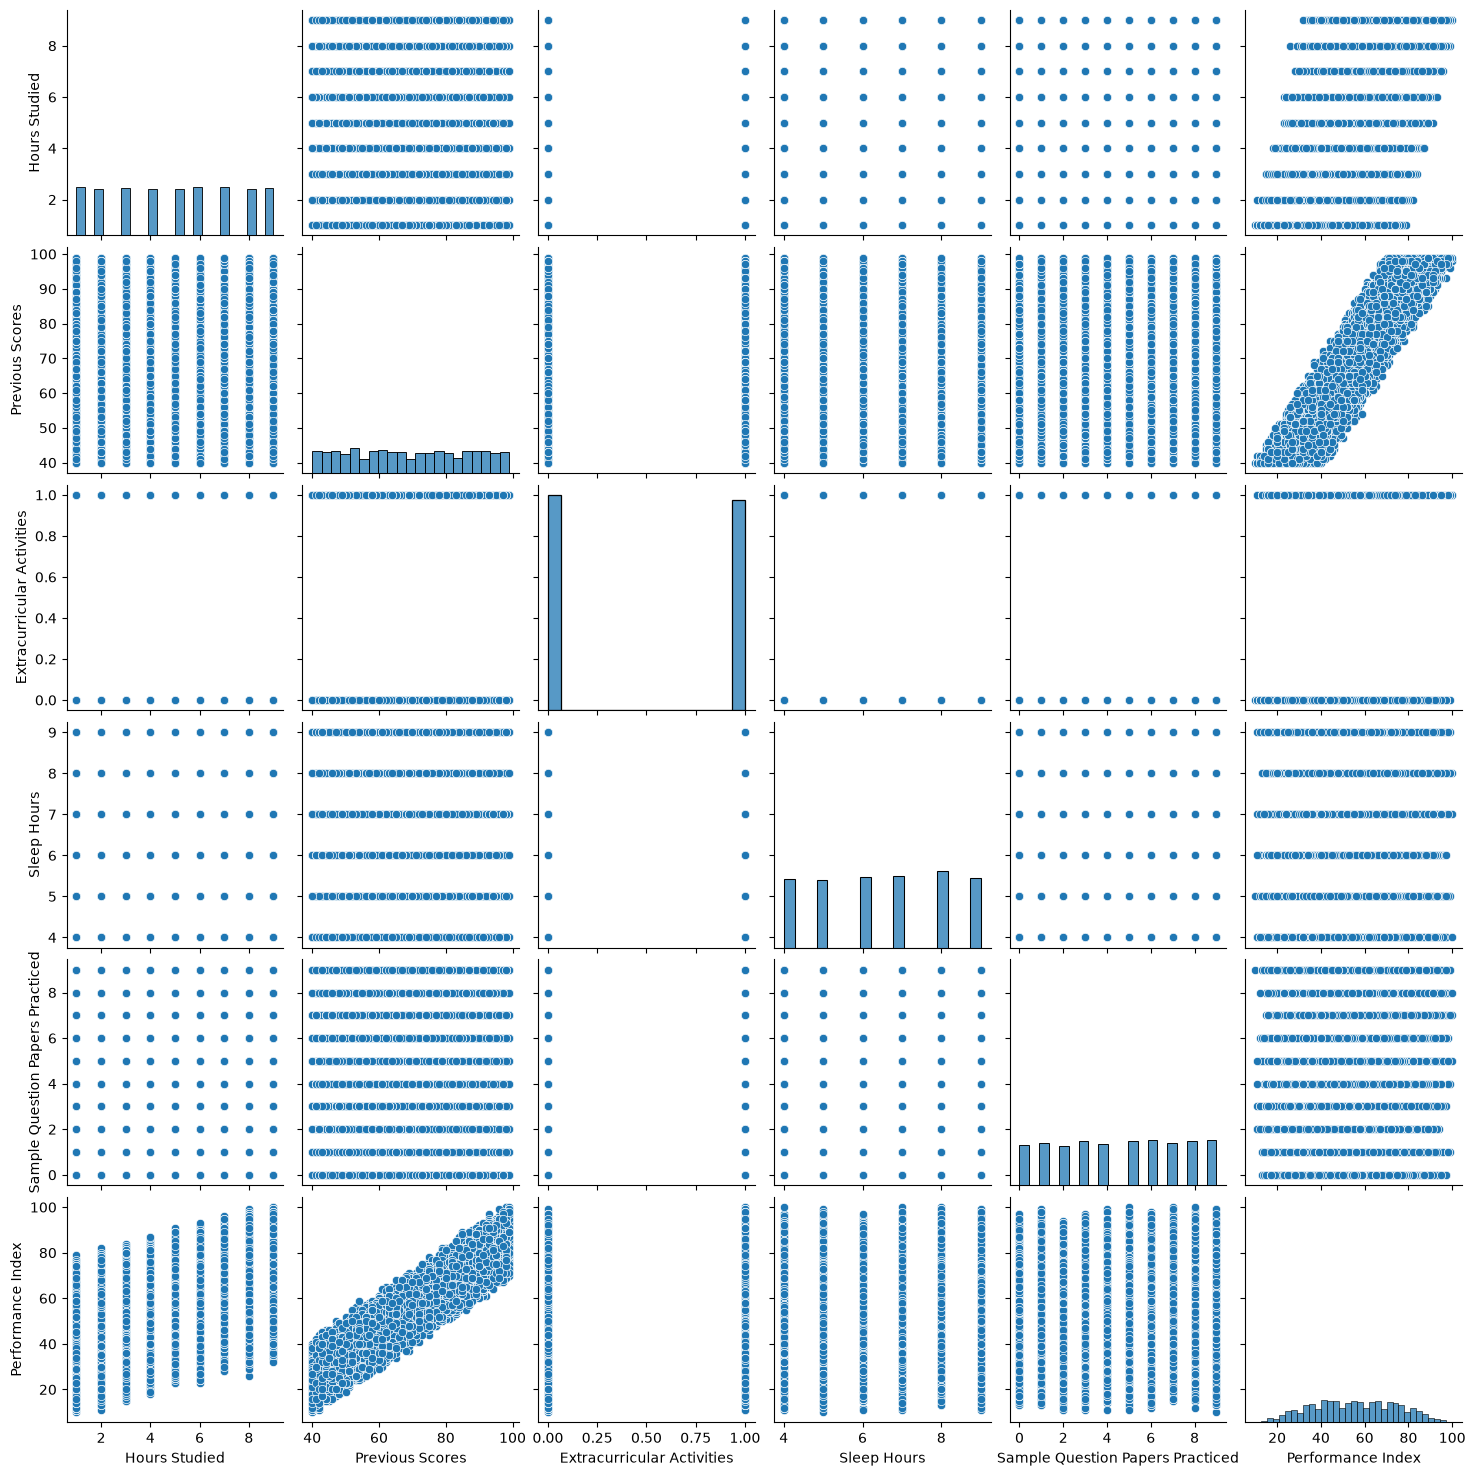

In [ ]:
sns.pairplot(df)

### split the data 

In [ ]:
x = df.drop(['Performance Index'],axis=1)
y = df['Performance Index']

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x , y , train_size = 0.7 ,random_state = 42)

### Train the model

In [ ]:
from sklearn.linear_model import LinearRegression

#create the model
model = LinearRegression()
#fit the model
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[2.85,1.02,0.56,0.47,0.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours Studied','Previous Scores','Extracurricular Activities', 'Sleep Hours','Sample Question Papers Practiced']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-33.97
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


### Evaluate The Model

##### On Training Set

In [ ]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_percentage_error , root_mean_squared_error , mean_absolute_error

y_pred = model.predict(x_train)

# calculate the metrics
r2 = r2_score(y_train,y_pred)
mse = mean_squared_error(y_train,y_pred)
mae = mean_absolute_error(y_train,y_pred)
mape = mean_absolute_percentage_error(y_train,y_pred)
rmse = root_mean_squared_error(y_train,y_pred)

# print the result
print(f"r2_score = {r2:.2f}")
print(f"Mean_squared_Error = {mse:.2f}")
print(f"Mean_absolute_Error = {mae:.2f}")
print(f"Mean_absolute_percentage_Error = {mape:.2f}")
print(f"Root_Mean_Squared_Error {rmse:.2f}")

r2_score = 0.99
Mean_squared_Error = 4.11
Mean_absolute_Error = 1.61
Mean_absolute_percentage_Error = 0.03
Root_Mean_Squared_Error 2.03


##### On Testing Set

In [ ]:
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_percentage_error , root_mean_squared_error , mean_absolute_error

y_pred = model.predict(x_test)

# calculate the metrics
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

# print the result
print(f"r2_score = {r2:.2f}")
print(f"Mean_squared_Error = {mse:.2f}")
print(f"Mean_absolute_Error = {mae:.2f}")
print(f"Mean_absolute_percentage_Error = {mape:.2f}")
print(f"Root_Mean_Squared_Error {rmse:.2f}")

r2_score = 0.99
Mean_squared_Error = 4.33
Mean_absolute_Error = 1.65
Mean_absolute_percentage_Error = 0.03
Root_Mean_Squared_Error 2.08


### Model Inference

In [ ]:
Performance_Index = model.predict([[7, 99, 1, 9, 1]])[0]
print(f"Predicted Performance Index: {Performance_Index:.2f}")

Predicted Performance Index: 91.76


c:\Users\saurabh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
